In [20]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import os, glob

# 이미지 리사이즈 함수
def resize_images(img_path):
    images = glob.glob(img_path + "/*.jpg") + glob.glob(img_path + "/*.jpeg")
    for img in images:
        old_img = Image.open(img)
        new_img = old_img.resize((28, 28), Image.ANTIALIAS)
        new_img.save(img, "JPEG")
    print(f"{img_path} : {len(images)}개 변환 완료")

# 모든 경로 리사이즈 실행
root_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper"
test_path = root_path + "/test"

for p in [root_path, test_path]:
    for folder in ['scissor', 'rock', 'paper']:
        resize_images(os.path.join(p, folder))

/aiffel/aiffel/rock_scissor_paper/scissor : 131개 변환 완료
/aiffel/aiffel/rock_scissor_paper/rock : 119개 변환 완료
/aiffel/aiffel/rock_scissor_paper/paper : 117개 변환 완료
/aiffel/aiffel/rock_scissor_paper/test/scissor : 100개 변환 완료
/aiffel/aiffel/rock_scissor_paper/test/rock : 100개 변환 완료
/aiffel/aiffel/rock_scissor_paper/test/paper : 100개 변환 완료


In [21]:
# 데이터 통합 (동료의 데이터를 합치고 무작위로 섞어 누수 방지)
def load_all_data(paths):
    total_count = 0
    for p in paths:
        for folder in ['scissor', 'rock', 'paper']:
            total_count += len(glob.glob(os.path.join(p, folder, "*.jpg")))
    
    imgs = np.zeros(total_count*28*28*3, dtype=np.int32).reshape(total_count, 28, 28, 3)
    labels = np.zeros(total_count, dtype=np.int32)

    idx = 0
    for p in paths:
        for label, folder in enumerate(['scissor', 'rock', 'paper']):
            for file in glob.glob(os.path.join(p, folder, "*.jpg")):
                img = np.array(Image.open(file), dtype=np.int32)
                imgs[idx,:,:,:] = img
                labels[idx] = label
                idx += 1
    return imgs, labels

# 전체 데이터 로드 및 정규화
(x_all, y_all) = load_all_data([root_path, test_path])
x_all_norm = x_all / 255.0

# 데이터 셔플 및 8:2 분리
indices = np.random.permutation(len(x_all_norm))
x_all_norm, y_all = x_all_norm[indices], y_all[indices]

split_idx = int(len(x_all_norm) * 0.8)
x_train, x_test = x_all_norm[:split_idx], x_all_norm[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f"학습 데이터: {x_train.shape}, 테스트 데이터: {x_test.shape}")

학습 데이터: (533, 28, 28, 3), 테스트 데이터: (134, 28, 28, 3)


In [23]:
# 레이어를 너무 깊게 쌓아 과적합 우려로 Conv2D 2개로 조정
# Dropout(0.3)은 루브릭의 오버피팅 해결 위해 적용

model = keras.models.Sequential([
    keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,3)),
    keras.layers.MaxPool2D(2,2),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 26, 26, 64)        1792      
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 11, 11, 128)       73856     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 5, 5, 128)         0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 3200)              0         
_________________________________________________________________
dense_6 (Dense)              (None, 128)               409728    
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)              

In [29]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 학습 실행
history = model.fit(x_train, y_train, epochs=20)

Epoch 1/20
17/17 [==============================] - 2s 99ms/step - loss: 0.0126 - accuracy: 1.0000
Epoch 2/20
17/17 [==============================] - 2s 99ms/step - loss: 0.0159 - accuracy: 0.9962
Epoch 3/20
17/17 [==============================] - 2s 98ms/step - loss: 0.0120 - accuracy: 0.9981
Epoch 4/20
17/17 [==============================] - 2s 96ms/step - loss: 0.0180 - accuracy: 0.9962
Epoch 5/20
17/17 [==============================] - 2s 107ms/step - loss: 0.0106 - accuracy: 0.9981
Epoch 6/20
17/17 [==============================] - 2s 96ms/step - loss: 0.0062 - accuracy: 1.0000
Epoch 7/20
17/17 [==============================] - 2s 97ms/step - loss: 0.0033 - accuracy: 1.0000
Epoch 8/20
17/17 [==============================] - 2s 98ms/step - loss: 0.0016 - accuracy: 1.0000
Epoch 9/20
17/17 [==============================] - 2s 104ms/step - loss: 0.0018 - accuracy: 1.0000
Epoch 10/20
17/17 [==============================] - 2s 97ms/step - loss: 0.0012 - accuracy: 1.0000
Epoch 1

In [25]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"최종 정확도: {test_accuracy:.4f}")

5/5 - 0s - loss: 0.0466 - accuracy: 0.9851
최종 정확도: 0.9851


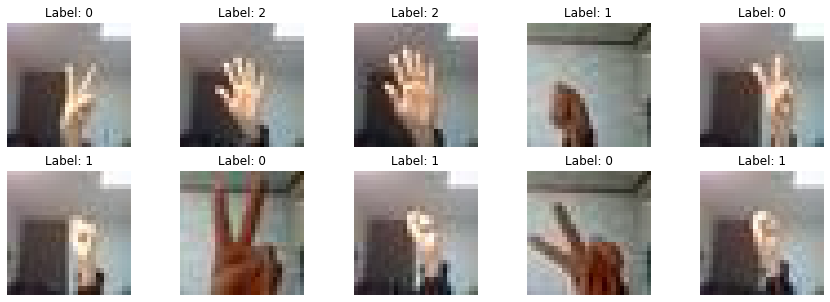

In [27]:
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for i in range(10):
    j = random.randint(0, len(x_train)-1)
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[j])
    plt.title(f"Label: {y_train[j]}")
    plt.axis('off')
plt.show()

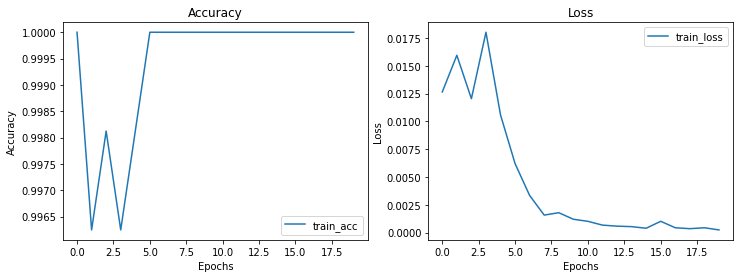

In [30]:
# 학습 결과 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()